# **Intra- and Inter-Similarity Densities**

Author: Aditya Khadkikar

Credit: https://github.com/serengil/deepface/blob/master/experiments/distance-to-confidence.ipynb

Original code from above adapted and moderately refactored for working with this project.

> Because of the files being excessively large in size, outputs are not stored. Run the notebooks to achieve the outputs. You need the necessary libraries in this notebook, and a ZIP folder of all of the images named as intra-sim.zip.

In [ ]:
! pip install deepface

# built-in dependencies
import itertools
import math, os

# 3rd party dependencies
import pandas as pd
pd.set_option('display.max_rows', None)
from deepface import DeepFace
from deepface.modules.verification import find_distance, find_threshold
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [13]:
detectors = ["mtcnn", "dlib", "retinaface"]
model_names = ["Facenet512", "VGG-Face", "ArcFace"]
distance_metrics = ["cosine", "euclidean"]

## **Preparing the images**

To be put in the form as shown below:

```py
identities = {
 "Angelina": ["img1.jpg", "img2.jpg", "img4.jpg"
    , "img5.jpg", "img6.jpg", "img7.jpg", "img10.jpg", "img11.jpg"],
 "Scarlett": ["img8.jpg", "img9.jpg"],
 "Jennifer": ["img3.jpg", "img12.jpg"],
 "Mark": ["img13.jpg", "img14.jpg", "img15.jpg"],
 "Jack": ["img16.jpg", "img17.jpg"],
 "Elon": ["img18.jpg", "img19.jpg"],
 "Jeff": ["img20.jpg", "img21.jpg"],
 "Marissa": ["img22.jpg", "img23.jpg"],
 "Sundar": ["img24.jpg", "img25.jpg"]
}
```

In [ ]:
! unzip intra-sim.zip

In [16]:
path = "intra-sim/"
identities = {}

for entry in os.listdir(path):
    person_collection = os.path.join(path, entry)

    if os.path.isdir(person_collection):
        identities[entry] = []
        for file_ in os.listdir(person_collection):
          identities[entry].append(str(entry+"/"+file_))

# Split into 3 subsets as the density peaks are improperly high
# 62 distinct individuals 'inter-similarity' vs 20 in the 'intra-similarity'
# hence split to 3 parts.
i_subsets = {}
i_subsets['1'] = {}
i_subsets['2'] = {}
i_subsets['3'] = {}

for k in list(identities.keys())[:20]:
    i_subsets['1'][k] = identities[k]

for k in list(identities.keys())[20:40]:
    i_subsets['2'][k] = identities[k]

for k in list(identities.keys())[40:]:
    i_subsets['3'][k] = identities[k]

## **Generate Embeddings**

In [17]:
# estimating the Bhattacharyya distance with Monte-Carlo based approach
def BD_mc(p, q, n=100):
  points = p.resample(n)
  p_pdf = p.pdf(points)
  q_pdf = q.pdf(points)
  return (np.sqrt(p_pdf * q_pdf)/p_pdf).mean()

In [19]:
def represent(img_name: str):
  if pivot.get(img_name) is None:
      embedding_objs = DeepFace.represent(img_path=img_name, model_name=model_name, detector_backend=detector_backend)

      if len(embedding_objs) > 1:
          print(f"{img_name} has more than one face!")
          embedding_objs = [embedding_objs[max(range(len(embedding_objs)), key=lambda index: embedding_objs[index]['face_confidence'])]]

      pivot[img_name] = [embedding_obj["embedding"] for embedding_obj in embedding_objs]
  return pivot[img_name]


-------
Running an experiment for Facenet512 & mtcnn...
-------



  0%|          | 7/96141 [00:03<13:06:15,  2.04it/s]

intra-sim/Silvio_Berlusconi_/17.png has more than one face!


  0%|          | 9/96141 [00:04<11:55:50,  2.24it/s]

intra-sim/Silvio_Berlusconi_/10.png has more than one face!


...

  4%|▍         | 3782/96141 [02:48<33:29, 45.97it/s]  

intra-sim/Jack_Straw_/12.png has more than one face!


  4%|▍         | 3972/96141 [02:57<36:45, 41.79it/s]  

intra-sim/Kofi_Annan_/18.png has more than one face!


100%|██████████| 96141/96141 [00:14<00:00, 6494.30it/s]


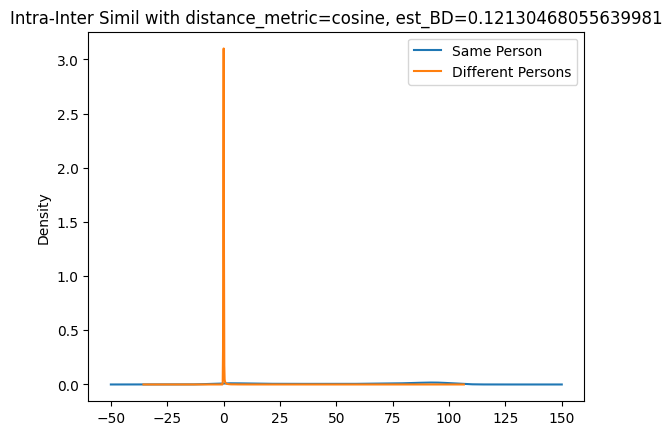

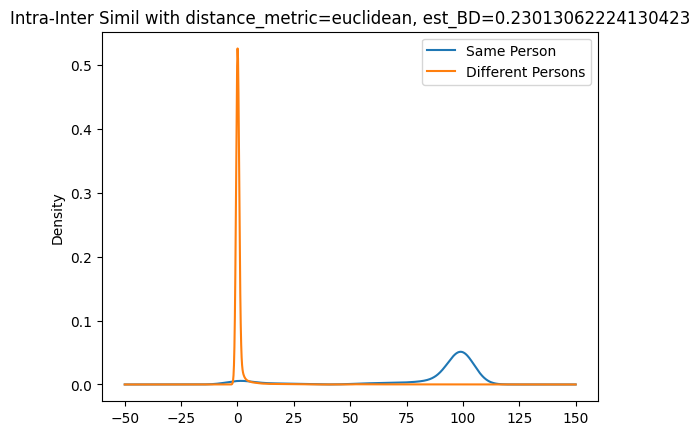


-------
Running an experiment for Facenet512 & dlib...
-------



  0%|          | 9/96141 [00:03<8:26:24,  3.16it/s]

intra-sim/Silvio_Berlusconi_/10.png has more than one face!


  0%|          | 16/96141 [00:05<8:11:13,  3.26it/s]

intra-sim/Silvio_Berlusconi_/1.png has more than one face!


...

  4%|▎         | 3592/96141 [02:18<31:26, 49.06it/s]  

intra-sim/Hans_Blix_/3.png has more than one face!


  4%|▎         | 3602/96141 [02:22<58:56, 26.16it/s]

intra-sim/Hans_Blix_/7.png has more than one face!
intra-sim/Hans_Blix_/14.png has more than one face!


100%|██████████| 96141/96141 [00:14<00:00, 6541.35it/s]


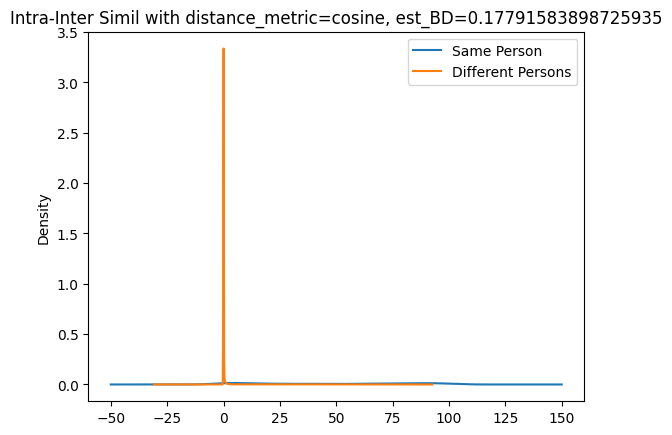

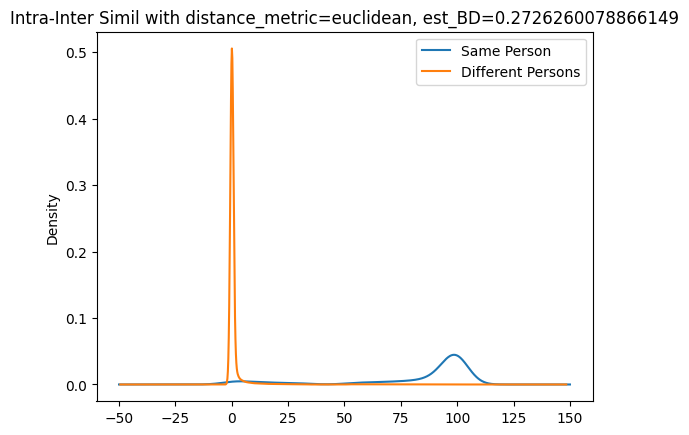


-------
Running an experiment for Facenet512 & retinaface...
-------



  0%|          | 2/96141 [00:00<10:28:01,  2.55it/s]

intra-sim/Silvio_Berlusconi_/6.png has more than one face!


  0%|          | 7/96141 [00:02<7:18:56,  3.65it/s]

intra-sim/Silvio_Berlusconi_/17.png has more than one face!


...

  4%|▍         | 3782/96141 [01:56<27:52, 55.23it/s]  

intra-sim/Jack_Straw_/12.png has more than one face!
intra-sim/Jack_Straw_/18.png has more than one face!


  4%|▍         | 3972/96141 [02:02<29:35, 51.91it/s]  

intra-sim/Kofi_Annan_/18.png has more than one face!


100%|██████████| 96141/96141 [00:16<00:00, 5916.43it/s]


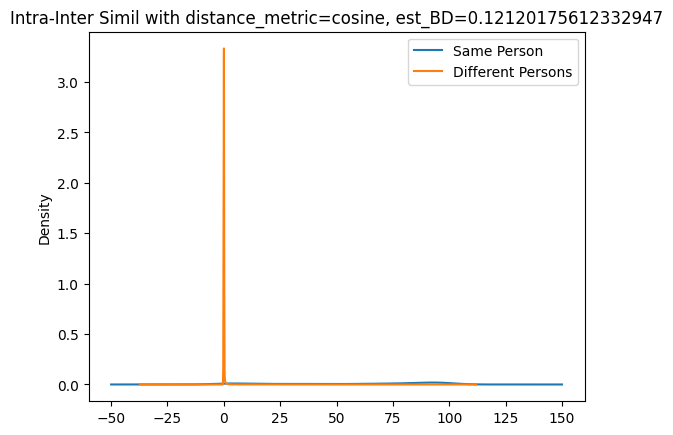

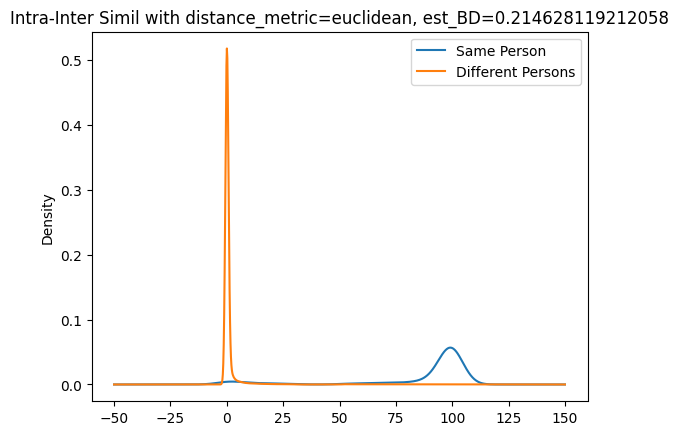


-------
Running an experiment for VGG-Face & mtcnn...
-------



  0%|          | 7/96141 [00:01<7:06:38,  3.76it/s]

intra-sim/Silvio_Berlusconi_/17.png has more than one face!


  0%|          | 9/96141 [00:02<7:13:53,  3.69it/s]

intra-sim/Silvio_Berlusconi_/10.png has more than one face!


...

  4%|▍         | 3782/96141 [01:41<26:35, 57.89it/s]

intra-sim/Jack_Straw_/12.png has more than one face!


  4%|▍         | 3972/96141 [01:45<23:31, 65.30it/s]

intra-sim/Kofi_Annan_/18.png has more than one face!


100%|██████████| 96141/96141 [01:00<00:00, 1599.83it/s]


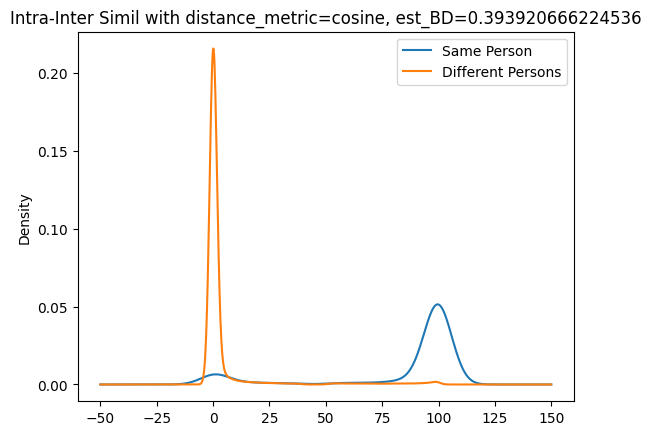

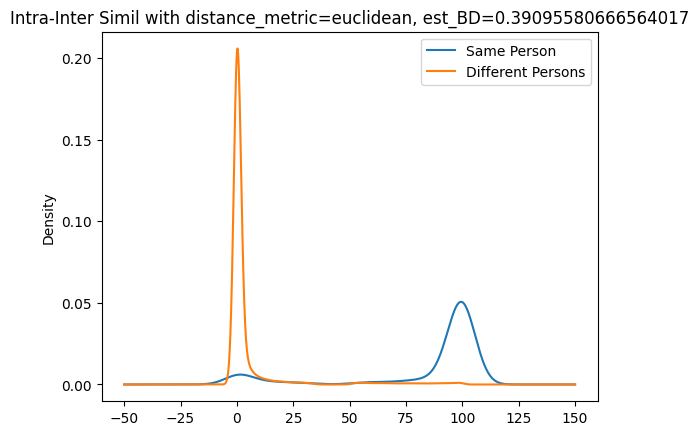


-------
Running an experiment for VGG-Face & dlib...
-------



  0%|          | 10/96141 [00:02<5:11:08,  5.15it/s]

intra-sim/Silvio_Berlusconi_/10.png has more than one face!


  0%|          | 16/96141 [00:03<7:20:35,  3.64it/s]

intra-sim/Silvio_Berlusconi_/1.png has more than one face!


...

  4%|▎         | 3402/96141 [01:08<23:56, 64.58it/s]

intra-sim/Alvaro_Uribe_/3.png has more than one face!


  4%|▎         | 3592/96141 [01:11<22:56, 67.24it/s]

intra-sim/Hans_Blix_/3.png has more than one face!
intra-sim/Hans_Blix_/7.png has more than one face!
intra-sim/Hans_Blix_/14.png has more than one face!


100%|██████████| 96141/96141 [01:01<00:00, 1562.00it/s]


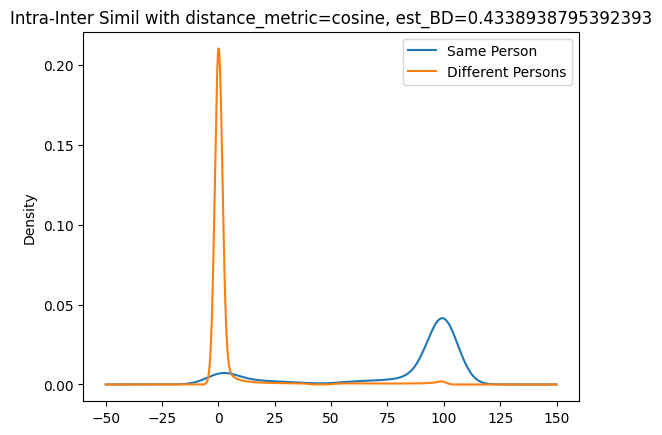

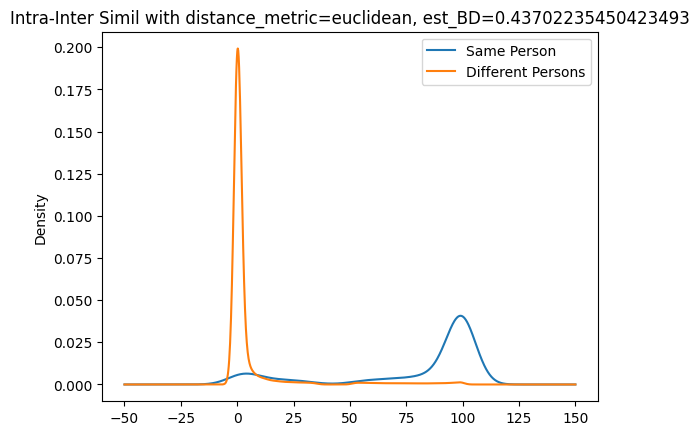


-------
Running an experiment for VGG-Face & retinaface...
-------



  0%|          | 3/96141 [00:00<6:25:59,  4.15it/s]

intra-sim/Silvio_Berlusconi_/6.png has more than one face!


  0%|          | 8/96141 [00:01<4:18:29,  6.20it/s]

intra-sim/Silvio_Berlusconi_/17.png has more than one face!


...

  4%|▍         | 3782/96141 [00:57<17:54, 85.95it/s]

intra-sim/Jack_Straw_/4.png has more than one face!
intra-sim/Jack_Straw_/12.png has more than one face!
intra-sim/Jack_Straw_/18.png has more than one face!


  4%|▍         | 3972/96141 [01:00<17:33, 87.49it/s]

intra-sim/Kofi_Annan_/18.png has more than one face!


100%|██████████| 96141/96141 [00:59<00:00, 1612.28it/s]


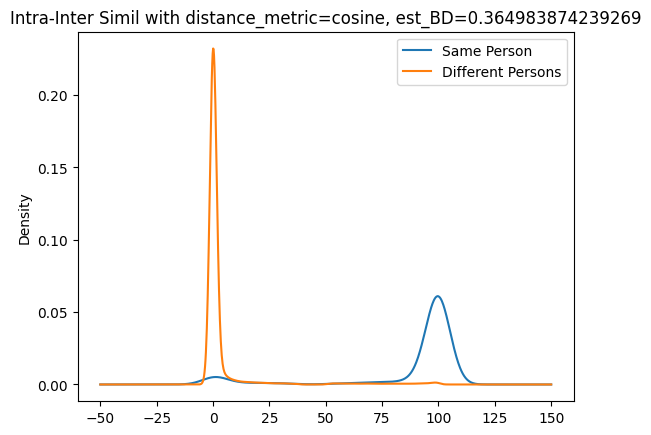

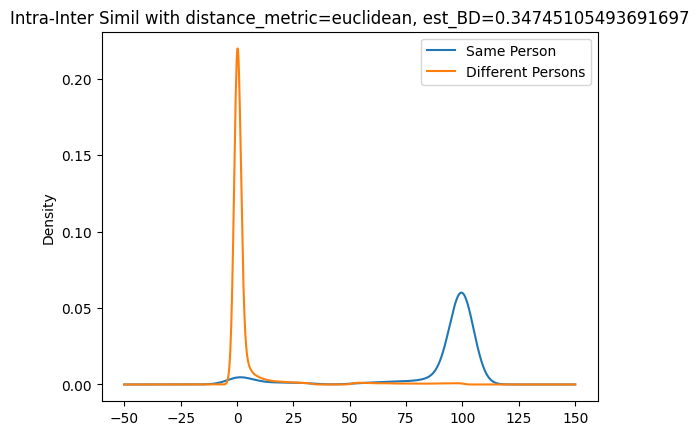


-------
Running an experiment for ArcFace & mtcnn...
-------



  0%|          | 7/96141 [00:02<7:48:47,  3.42it/s]

intra-sim/Silvio_Berlusconi_/17.png has more than one face!


  0%|          | 9/96141 [00:02<7:29:04,  3.57it/s]

intra-sim/Silvio_Berlusconi_/10.png has more than one face!


...

  4%|▍         | 3782/96141 [02:03<30:30, 50.45it/s]  

intra-sim/Jack_Straw_/12.png has more than one face!


  4%|▍         | 3972/96141 [02:09<32:45, 46.90it/s]  

intra-sim/Kofi_Annan_/18.png has more than one face!


100%|██████████| 96141/96141 [00:15<00:00, 6201.75it/s]


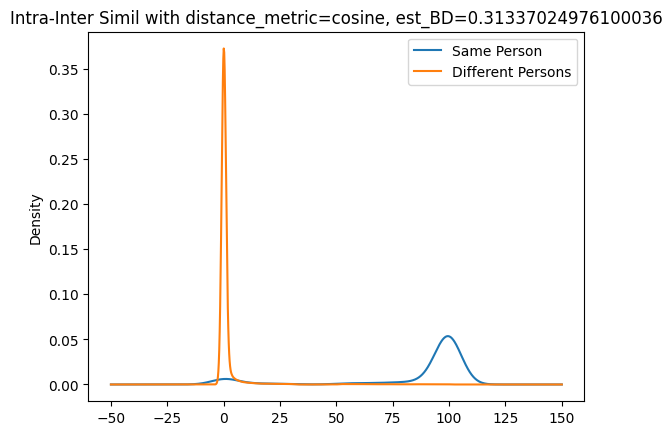

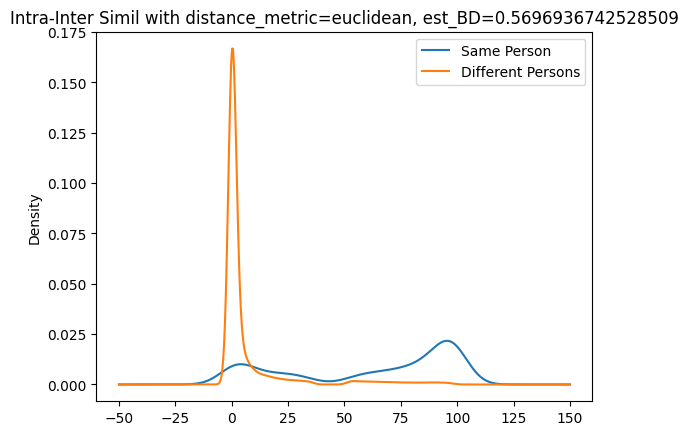


-------
Running an experiment for ArcFace & dlib...
-------



  0%|          | 9/96141 [00:03<7:03:12,  3.79it/s]

intra-sim/Silvio_Berlusconi_/10.png has more than one face!


  0%|          | 16/96141 [00:04<6:01:38,  4.43it/s]

intra-sim/Silvio_Berlusconi_/1.png has more than one face!


...

  4%|▎         | 3402/96141 [01:30<31:31, 49.04it/s]

intra-sim/Alvaro_Uribe_/3.png has more than one face!


  4%|▎         | 3592/96141 [01:35<30:03, 51.32it/s]

intra-sim/Hans_Blix_/3.png has more than one face!
intra-sim/Hans_Blix_/7.png has more than one face!
intra-sim/Hans_Blix_/14.png has more than one face!


100%|██████████| 96141/96141 [00:15<00:00, 6021.76it/s]


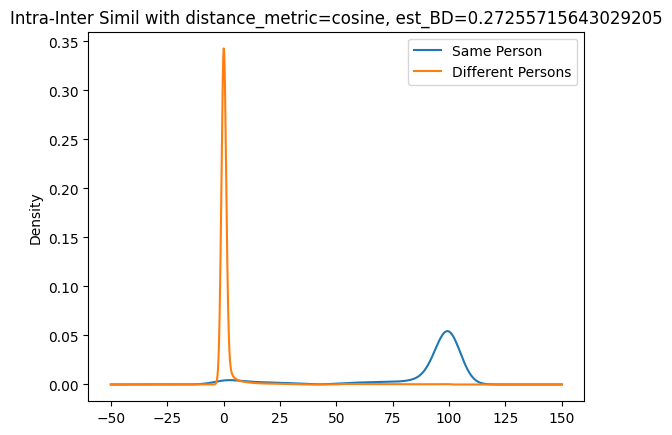

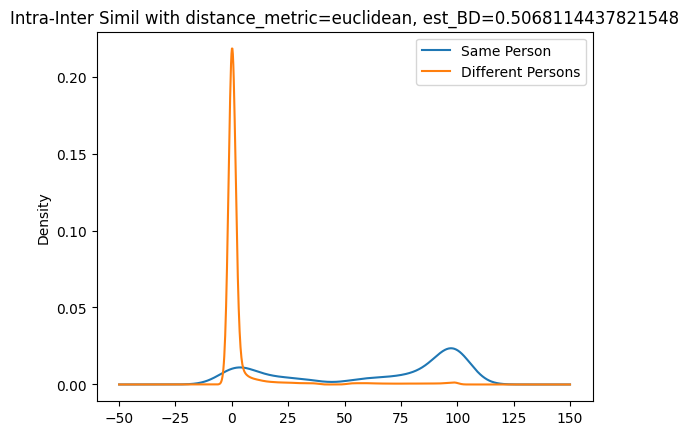


-------
Running an experiment for ArcFace & retinaface...
-------



  0%|          | 2/96141 [00:00<7:29:18,  3.57it/s] 

intra-sim/Silvio_Berlusconi_/6.png has more than one face!


  0%|          | 8/96141 [00:01<5:10:29,  5.16it/s]

intra-sim/Silvio_Berlusconi_/17.png has more than one face!


...

  4%|▍         | 3782/96141 [01:16<22:44, 67.67it/s]

intra-sim/Jack_Straw_/4.png has more than one face!
intra-sim/Jack_Straw_/12.png has more than one face!
intra-sim/Jack_Straw_/18.png has more than one face!


  4%|▍         | 3972/96141 [01:20<23:16, 66.02it/s]

intra-sim/Kofi_Annan_/18.png has more than one face!


100%|██████████| 96141/96141 [00:16<00:00, 5684.45it/s]


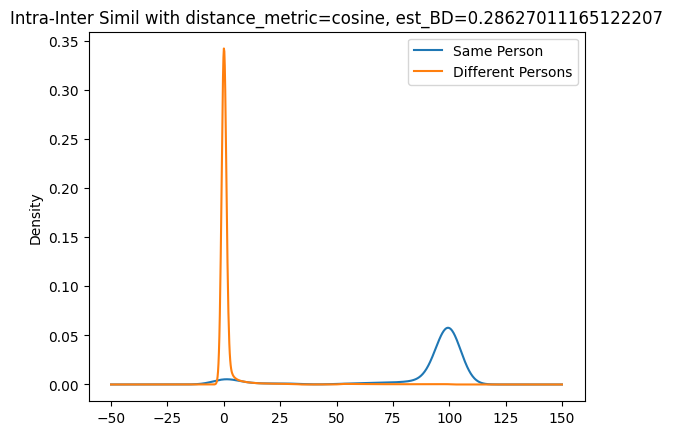

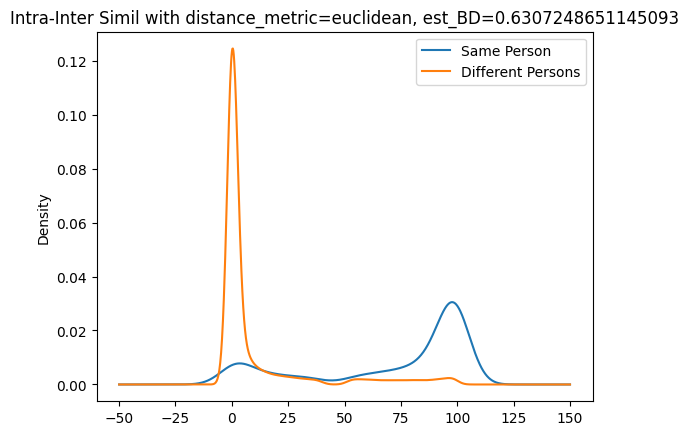

In [ ]:
for subset in ['1', '2', '3']:
  identities = i_subsets[subset]
  for model_idx in range(len(model_names)):
    for detector_backend in detectors:
      model_name = model_names[model_idx]
      print(f"\n-------\nRunning an experiment for {model_name} & {detector_backend}...\n-------\n")

      # build models in advance
      model = DeepFace.build_model(model_name)
      detector = DeepFace.build_model(task="face_detector", model_name=detector_backend)

      positives = []
      for key, values in identities.items():
        for i in range(0, len(values)-1):
          for j in range(i+1, len(values)):
            positive = []
            positive.append(values[i])
            positive.append(values[j])
            positives.append(positive)

      positives = pd.DataFrame(positives, columns = ["file_x", "file_y"])
      positives["actual"] = "Same Person"

      #############

      samples_list = list(identities.values())

      negatives = []
      for i in range(0, len(identities) - 1):
        for j in range(i+1, len(identities)):
          cross_product = itertools.product(samples_list[i], samples_list[j])
          cross_product = list(cross_product)

          for cross_sample in cross_product:
            negative = []
            negative.append(cross_sample[0])
            negative.append(cross_sample[1])
            negatives.append(negative)

      negatives = pd.DataFrame(negatives, columns = ["file_x", "file_y"])
      negatives["actual"] = "Different Persons"

      #############

      df = pd.concat([positives, negatives]).reset_index(drop = True)

      df.file_x = "intra-sim/"+df.file_x
      df.file_y = "intra-sim/"+df.file_y

      pivot = {}

      img1_embeddings = []
      img2_embeddings = []
      for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
        try:
          img1_embeddings = img1_embeddings + represent(instance["file_x"])
          img2_embeddings = img2_embeddings + represent(instance["file_y"])
        except ValueError as e:
          img1_embeddings = []
          img2_embeddings = []
          print(e)

      df["img1_embeddings"] = img1_embeddings
      df["img2_embeddings"] = img2_embeddings

      for distance_metric in distance_metrics:
          distances = []
          for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
              img1_embeddings = instance["img1_embeddings"]
              img2_embeddings = instance["img2_embeddings"]

              distance = find_distance(
                  alpha_embedding=img1_embeddings,
                  beta_embedding=img2_embeddings,
                  distance_metric=distance_metric
              )
              distances.append(distance)

          df[distance_metric] = distances

      for distance_metric in distance_metrics:
          threshold = find_threshold(model_name=model_name, distance_metric=distance_metric)
          df[f"{distance_metric}_threshold"] = threshold
          df[f"{distance_metric}_decision"] = 0
          idx = df[df[distance_metric] <= threshold].index
          df.loc[idx, f"{distance_metric}_decision"] = 1

      confidence_metrics = {}

      for distance_metric in distance_metrics:
          max_value = df[distance_metric].max()

          X = df[distance_metric].values.reshape(-1, 1)

          # normalize the distance values before feeding them to the model
          if max_value > 1:
              X = X / max_value

          y = df[f"{distance_metric}_decision"].values

          model = LogisticRegression().fit(X, y)

          w = model.coef_[0][0]
          b = model.intercept_[0]

          confidence_metrics[distance_metric] = {
              "w": w,
              "b": b,
              "normalizer": max_value,
          }

          confidences =[]
          for index, instance in df.iterrows():
              distance = instance[distance_metric]

              if max_value > 1:
                  distance = distance / max_value

              z = w * distance + b
              confidence = 100 / (1 + math.exp(-z))

              confidences.append(confidence)

          df[distance_metric + "_confidence"] = confidences

          confidence_metrics[distance_metric]["denorm_max_true"] = df[df[f"{distance_metric}_decision"] == 1][distance_metric + "_confidence"].max()
          confidence_metrics[distance_metric]["denorm_min_true"] = df[df[f"{distance_metric}_decision"] == 1][distance_metric + "_confidence"].min()

          confidence_metrics[distance_metric]["denorm_max_false"] = df[df[f"{distance_metric}_decision"] == 0][distance_metric + "_confidence"].max()
          confidence_metrics[distance_metric]["denorm_min_false"] = df[df[f"{distance_metric}_decision"] == 0][distance_metric + "_confidence"].min()

      # denormalize confidence scores
      for distance_metric in distance_metrics:
          for index, instance in df.iterrows():
              current_distance = instance[distance_metric]
              threshold = find_threshold(model_name=model_name, distance_metric=distance_metric)

              prediction = "same person" if current_distance <= threshold else "different persons"

              # denormalize same person predictions
              if prediction == "same person":
                  min_orginal = confidence_metrics[distance_metric]["denorm_min_true"]
                  max_orginal = confidence_metrics[distance_metric]["denorm_max_true"]
                  min_target = max(51, min_orginal)
                  max_target = 100
              else:
                  min_orginal = confidence_metrics[distance_metric]["denorm_min_false"]
                  max_orginal = confidence_metrics[distance_metric]["denorm_max_false"]
                  min_target = 0
                  max_target = min(49, max_orginal)

              confidence = instance[f"{distance_metric}_confidence"]

              confidence_new = (
                  (confidence - min_orginal) / (max_orginal - min_orginal)
              ) * (max_target - min_target) + min_target

              confidence_new = float(confidence_new)

              # print(f"{prediction}: {confidence}  -> {confidence_new}")

              df.loc[index, f"{distance_metric}_confidence"] = confidence_new

          df[df.actual == "Same Person"][f"{distance_metric}_confidence"].plot.kde(label="Same Person")
          df[df.actual == "Different Persons"][f"{distance_metric}_confidence"].plot.kde(label="Different Persons")

          intra = stats.gaussian_kde(df[df.actual == "Same Person"][f"{distance_metric}_confidence"])
          inter = stats.gaussian_kde(df[df.actual == "Different Persons"][f"{distance_metric}_confidence"])

          plt.title(f'Intra-Inter Simil with distance_metric={distance_metric}, est_BD={BD_mc(inter, intra, n=3000)}')
          plt.legend()
          plt.savefig(f"subset-{subset}-{detector_backend}-{model_name}-{distance_metric}.png")
          plt.show()